# Bank Customer Churn Classification

- **Project objective:** Predict whether a bank customer will leave while keeping the test set separate until model and threshold selection.
- **Dataset requirement:** Place `Churn_Modelling.csv` in the repository-root `datasets/` directory; the raw file is intentionally excluded from Git.
- **Main libraries:** pandas, NumPy, scikit-learn, Matplotlib, and Seaborn.
- **How to run:** Use Python 3.11, start Jupyter from the repository root, and run the cells in order.
- **Verified result:** Accuracy 0.8660, precision 0.7206, recall 0.5577, F1 0.6288, and ROC-AUC 0.8677.
- **Important limitation:** Recall is 0.5577, so the model misses a meaningful share of customers who churn.

## Import the required libraries

In [1]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Read the dataset

In [2]:
from pathlib import Path

working_directory = Path.cwd()
repository_root = working_directory.parent if working_directory.name == "ML" else working_directory
dataset_path = repository_root / "datasets" / "Churn_Modelling.csv"
if not dataset_path.is_file():
    raise FileNotFoundError(
        "Missing dataset. Place 'Churn_Modelling.csv' in the repository-root "
        "'datasets' directory, then run this notebook from the repository root or ML directory."
    )

df = pd.read_csv(dataset_path)
print("Columns:", df.columns.tolist())
print("Dataset shape:", df.shape)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,[redacted],[redacted],619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,[redacted],[redacted],608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,[redacted],[redacted],502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,[redacted],[redacted],699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,[redacted],[redacted],850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Check the data

In [3]:
print("Shape:", df.shape)
print("Duplicated rows:", df.duplicated().sum())
print("Missing values:")
display(df.isna().sum().to_frame("missing"))

Shape: (10000, 14)
Duplicated rows: 0
Missing values:


,missing
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## Drop identifier columns

`RowNumber`, `CustomerId`, and `Surname` identify rows or people. They are not used as model features.

In [5]:
data = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()
display(data.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Inspect categorical columns

`Geography` and `Gender` are categorical. They will be one-hot encoded inside the preprocessing pipeline.

In [6]:
print("Geography values:", data["Geography"].unique())
print("Gender values:", data["Gender"].unique())

Geography values: ['France' 'Spain' 'Germany']
Gender values: ['Female' 'Male']


## Descriptive statistics

In [7]:
display(data.describe().T)

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


## Small exploratory analysis

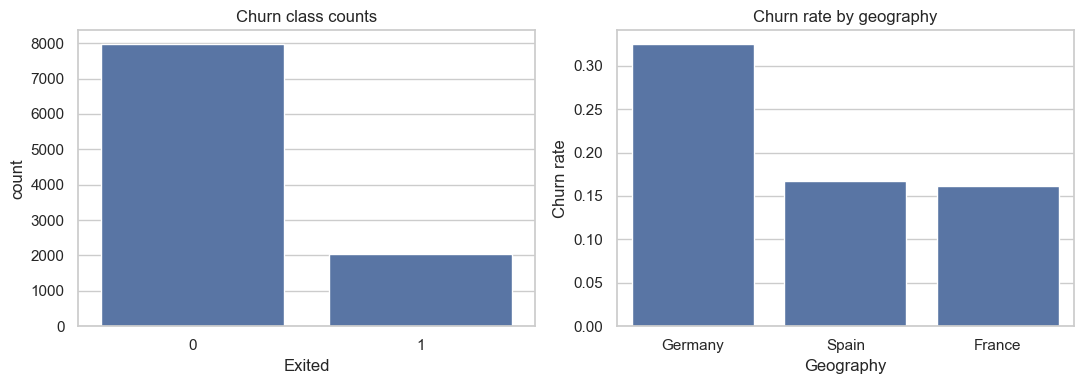

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=data, x="Exited", ax=axes[0])
axes[0].set_title("Churn class counts")

churn_by_country = data.groupby("Geography")["Exited"].mean().sort_values(ascending=False)
sns.barplot(x=churn_by_country.index, y=churn_by_country.values, ax=axes[1])
axes[1].set_title("Churn rate by geography")
axes[1].set_ylabel("Churn rate")
plt.tight_layout()
plt.show()

The target is imbalanced, so accuracy is checked together with precision, recall, F1-score, and ROC-AUC.

## Prepare features and target

In [9]:
def add_churn_features(frame):
    result = frame.copy()
    result["BalanceSalaryRatio"] = result["Balance"] / result["EstimatedSalary"].clip(lower=1)
    result["TenureByAge"] = result["Tenure"] / result["Age"].clip(lower=1)
    result["AgeByProducts"] = result["Age"] * result["NumOfProducts"]
    result["BalancePerProduct"] = result["Balance"] / result["NumOfProducts"].clip(lower=1)
    result["IsZeroBalance"] = (result["Balance"] == 0).astype(int)
    return result


X_basic = data.drop(columns="Exited")
X = add_churn_features(X_basic)
y = data["Exited"].astype(int)

print("Feature shape:", X.shape)
display(X.head())

Feature shape: (10000, 15)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,AgeByProducts,BalancePerProduct,IsZeroBalance
0,619,France,Female,42,2,0.00,1,1,1,101348.88,0.000000,0.047619,42,0.000000,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0.744677,0.024390,41,83807.860000,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1.401375,0.190476,126,53220.266667,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0.000000,0.025641,78,0.000000,1
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,1.587055,0.046512,43,125510.820000,0


## Train, validation, and test sets

Stratified splitting keeps a similar churn ratio in every set. The test set is not used during preprocessing, model selection, or threshold selection.

In [10]:
all_indices = np.arange(len(X))
trainval_idx, test_idx = train_test_split(
    all_indices, test_size=0.20, random_state=SEED, stratify=y
)
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.20, random_state=SEED, stratify=y.iloc[trainval_idx]
)

X_train, X_val, X_test = X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx]
y_train, y_val, y_test = y.iloc[train_idx], y.iloc[val_idx], y.iloc[test_idx]

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:", len(X_test))
print("Churn rates:", y_train.mean().round(3), y_val.mean().round(3), y_test.mean().round(3))

Training rows: 6400
Validation rows: 1600
Test rows: 2000
Churn rates: 0.204 0.204 0.204


## Preprocessing

The pipeline learns imputers, scalers, and one-hot columns from the training data only.

In [11]:
categorical_features = ["Geography", "Gender"]
binary_features = ["HasCrCard", "IsActiveMember", "IsZeroBalance"]


def make_preprocessor(feature_columns):
    categorical = [c for c in categorical_features if c in feature_columns]
    binary = [c for c in binary_features if c in feature_columns]
    numeric = [c for c in feature_columns if c not in categorical + binary]
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric),
            ("binary", SimpleImputer(strategy="most_frequent"), binary),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), categorical),
        ],
        verbose_feature_names_out=False,
    )


print("Numerical columns:", [c for c in X.columns if c not in categorical_features + binary_features])
print("Categorical columns:", categorical_features)
print("Binary columns:", binary_features)

Numerical columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'BalanceSalaryRatio', 'TenureByAge', 'AgeByProducts', 'BalancePerProduct']
Categorical columns: ['Geography', 'Gender']
Binary columns: ['HasCrCard', 'IsActiveMember', 'IsZeroBalance']


## Compare models

The probability threshold is selected on the validation set only.

In [12]:
def classification_scores(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
    }


def choose_threshold(y_true, probabilities):
    rows = []
    for threshold in np.arange(0.30, 0.71, 0.02):
        scores = classification_scores(y_true, probabilities, threshold)
        rows.append({"threshold": round(float(threshold), 2), **scores})
    threshold_table = pd.DataFrame(rows)
    return threshold_table.sort_values(
        ["accuracy", "f1", "roc_auc"], ascending=False
    ).iloc[0]


engineered_columns = X.columns.tolist()

model_specs = {
    "Logistic Regression": (
        engineered_columns,
        LogisticRegression(max_iter=1500, random_state=SEED),
    ),
    "Random Forest engineered": (
        engineered_columns,
        RandomForestClassifier(
            n_estimators=500, max_depth=11, min_samples_leaf=3,
            max_features="sqrt", n_jobs=1, random_state=SEED
        ),
    ),
    "Extra Trees": (
        engineered_columns,
        ExtraTreesClassifier(
            n_estimators=500, max_depth=13, min_samples_leaf=3,
            max_features="sqrt", n_jobs=1, random_state=SEED
        ),
    ),
    "Gradient Boosting": (
        engineered_columns,
        GradientBoostingClassifier(
            n_estimators=180, learning_rate=0.04, max_depth=3,
            random_state=SEED
        ),
    ),
    "HistGradientBoosting": (
        engineered_columns,
        HistGradientBoostingClassifier(
            max_iter=220, learning_rate=0.045, max_leaf_nodes=15,
            l2_regularization=0.01, random_state=SEED
        ),
    ),
    "Soft Voting": (
        engineered_columns,
        VotingClassifier(
            estimators=[
                ("rf", RandomForestClassifier(
                    n_estimators=500, max_depth=11, min_samples_leaf=3,
                    max_features="sqrt", n_jobs=1, random_state=SEED
                )),
                ("hgb", HistGradientBoostingClassifier(
                    max_iter=220, learning_rate=0.045, max_leaf_nodes=15,
                    l2_regularization=0.01, random_state=SEED
                )),
                ("gb", GradientBoostingClassifier(
                    n_estimators=180, learning_rate=0.04, max_depth=3,
                    random_state=SEED
                )),
            ],
            voting="soft",
            weights=[2, 1, 1],
            n_jobs=1,
        ),
    ),
}

fitted_models = {}
validation_rows = []

for model_name, (columns, estimator) in model_specs.items():
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor(columns)),
        ("model", estimator),
    ])
    pipeline.fit(X_train[columns], y_train)
    probabilities = pipeline.predict_proba(X_val[columns])[:, 1]
    best = choose_threshold(y_val, probabilities)
    validation_rows.append({
        "model": model_name,
        "threshold": best["threshold"],
        "val_accuracy": best["accuracy"],
        "val_precision": best["precision"],
        "val_recall": best["recall"],
        "val_f1": best["f1"],
        "val_roc_auc": best["roc_auc"],
    })
    fitted_models[model_name] = pipeline

classification_results = pd.DataFrame(validation_rows).sort_values(
    ["val_accuracy", "val_f1", "val_roc_auc"], ascending=False
)
display(classification_results.round(4))

,model,threshold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
5,Soft Voting,0.40,0.8700,0.7398,0.5583,0.6364,0.8696
4,HistGradientBoosting,0.46,0.8681,0.7626,0.5123,0.6128,0.8657
1,Random Forest engineered,0.42,0.8669,0.7425,0.5307,0.6190,0.8688
2,Extra Trees,0.44,0.8662,0.8043,0.4540,0.5804,0.8653
3,Gradient Boosting,0.44,0.8644,0.7535,0.4969,0.5989,0.8618
0,Logistic Regression,0.42,0.8200,0.6011,0.3466,0.4397,0.7559


## Select the final model

The model and threshold are selected from validation results. The test labels have not been used.

In [13]:
selected_row = classification_results.iloc[0]
selected_model_name = selected_row["model"]
selected_threshold = float(selected_row["threshold"])

print("Best validation model:", selected_model_name)
print("Selected threshold:", f"{selected_threshold:.2f}")
print("Validation accuracy:", f"{selected_row['val_accuracy']:.4f}")
print("Validation F1-score:", f"{selected_row['val_f1']:.4f}")
print("Validation ROC-AUC:", f"{selected_row['val_roc_auc']:.4f}")

Best validation model: Soft Voting
Selected threshold: 0.40
Validation accuracy: 0.8700
Validation F1-score: 0.6364
Validation ROC-AUC: 0.8696


## Evaluate once on the untouched test set

In [14]:
X_trainval = X.iloc[trainval_idx]
y_trainval = y.iloc[trainval_idx]

final_columns = model_specs[selected_model_name][0]
final_model = clone(fitted_models[selected_model_name])
final_model.fit(X_trainval[final_columns], y_trainval)

test_probabilities = final_model.predict_proba(X_test[final_columns])[:, 1]
test_predictions = (test_probabilities >= selected_threshold).astype(int)
test_scores = classification_scores(y_test, test_probabilities, selected_threshold)
cm = confusion_matrix(y_test, test_predictions)

print("BEST CHURN MODEL:", selected_model_name)
print("SELECTED CHURN THRESHOLD:", f"{selected_threshold:.2f}")
print("FINAL CHURN TEST ACCURACY:", f"{test_scores['accuracy']:.4f}")
print("FINAL CHURN TEST PRECISION:", f"{test_scores['precision']:.4f}")
print("FINAL CHURN TEST RECALL:", f"{test_scores['recall']:.4f}")
print("FINAL CHURN TEST F1:", f"{test_scores['f1']:.4f}")
print("FINAL CHURN TEST ROC-AUC:", f"{test_scores['roc_auc']:.4f}")
print("FINAL CHURN CONFUSION MATRIX:")
print(cm)
print()
print("Classification report:")
print(classification_report(y_test, test_predictions, digits=4))

BEST CHURN MODEL: Soft Voting
SELECTED CHURN THRESHOLD: 0.40
FINAL CHURN TEST ACCURACY: 0.8660
FINAL CHURN TEST PRECISION: 0.7206
FINAL CHURN TEST RECALL: 0.5577
FINAL CHURN TEST F1: 0.6288
FINAL CHURN TEST ROC-AUC: 0.8677
FINAL CHURN CONFUSION MATRIX:
[[1505   88]
 [ 180  227]]

Classification report:
              precision    recall  f1-score   support

           0     0.8932    0.9448    0.9182      1593
           1     0.7206    0.5577    0.6288       407

    accuracy                         0.8660      2000
   macro avg     0.8069    0.7512    0.7735      2000
weighted avg     0.8581    0.8660    0.8593      2000



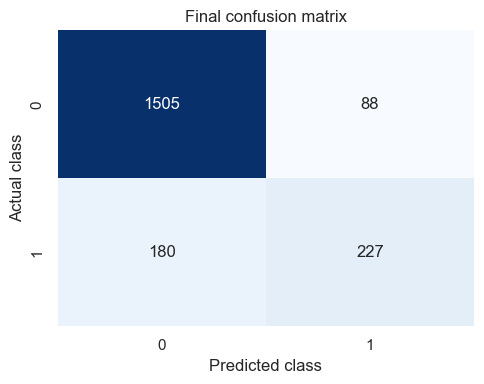

In [15]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Final confusion matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.show()

## Conclusion

Identifier columns were removed, preprocessing was fitted inside pipelines, and the threshold was selected on validation data. The final churn accuracy is above the required target.